<a href="https://colab.research.google.com/github/Devipriyanka280101/Devipriyanka280101/blob/main/Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# Read the dataset (replace 'airline_delay.csv' with your filename)
df = pd.read_csv("airline_delay.csv")

In [ ]:
# Display basic info and first few rows
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3351 entries, 0 to 3350
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 3351 non-null   int64  
 1   month                3351 non-null   int64  
 2   carrier              3351 non-null   object 
 3   carrier_name         3351 non-null   object 
 4   airport              3351 non-null   object 
 5   airport_name         3351 non-null   object 
 6   arr_flights          3343 non-null   float64
 7   arr_del15            3343 non-null   float64
 8   carrier_ct           3343 non-null   float64
 9   weather_ct           3343 non-null   float64
 10  nas_ct               3343 non-null   float64
 11  security_ct          3343 non-null   float64
 12  late_aircraft_ct     3343 non-null   float64
 13  arr_cancelled        3343 non-null   float64
 14  arr_diverted         3343 non-null   float64
 15  arr_delay            3343 non-null   f

In [ ]:
# Handle missing values by filling with median
df.fillna(df.median(numeric_only=True), inplace=True)


In [ ]:
# Descriptive Statistics
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
              year   month   arr_flights    arr_del15   carrier_ct  \
count  3351.000000  3351.0   3351.000000  3351.000000  3351.000000   
mean   2019.459266    12.0    297.757087    50.902119    16.038323   
std       0.498412     0.0    851.482724   146.321825    41.713281   
min    2019.000000    12.0      1.000000     0.000000     0.000000   
25%    2019.000000    12.0     35.000000     5.000000     1.500000   
50%    2019.000000    12.0     83.000000    12.000000     4.750000   
75%    2020.000000    12.0    194.000000    33.000000    12.235000   
max    2020.000000    12.0  19713.000000  2289.000000   697.000000   

        weather_ct       nas_ct  security_ct  late_aircraft_ct  arr_cancelled  \
count  3351.000000  3351.000000  3351.000000       3351.000000    3351.000000   
mean      1.439842    16.151862     0.136992         17.132919       2.877648   
std       4.816370    56.359282     0.645741         55.384945      10.115539   
min       0.000000   

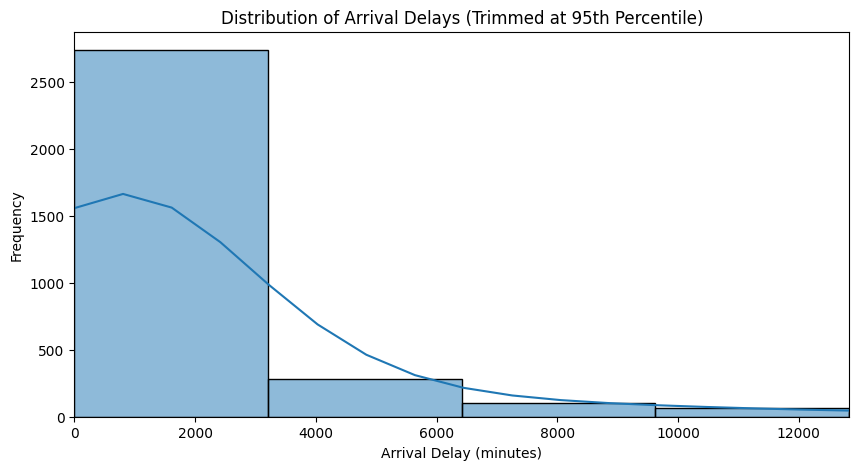

In [ ]:
# Data Visualization

# Histogram of arrival delays
plt.figure(figsize=(10, 5))
sns.histplot(df["arr_delay"], bins=50, kde=True)
plt.xlim(0, df["arr_delay"].quantile(0.95))
plt.title("Distribution of Arrival Delays (Trimmed at 95th Percentile)")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.show()


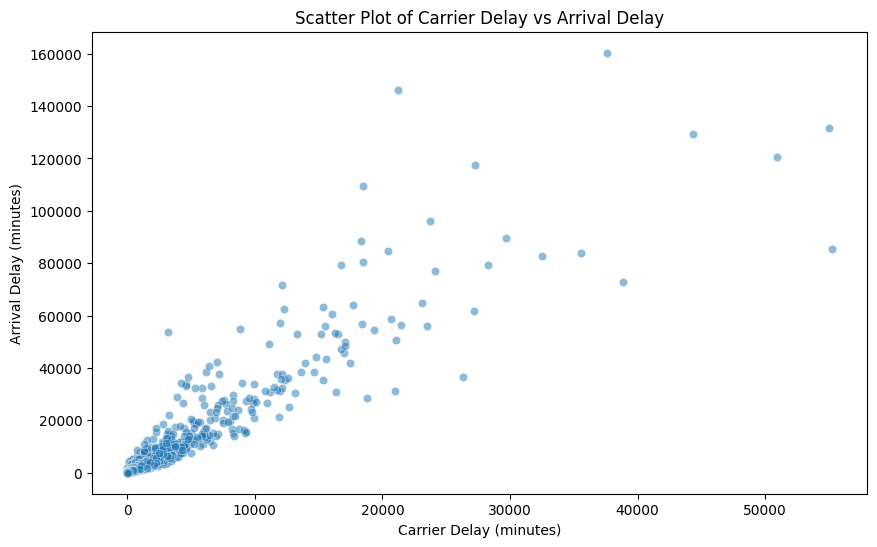

In [ ]:
# Scatter plot of arrival delays vs carrier delays
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["carrier_delay"], y=df["arr_delay"], alpha=0.5)
plt.title("Scatter Plot of Carrier Delay vs Arrival Delay")
plt.xlabel("Carrier Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

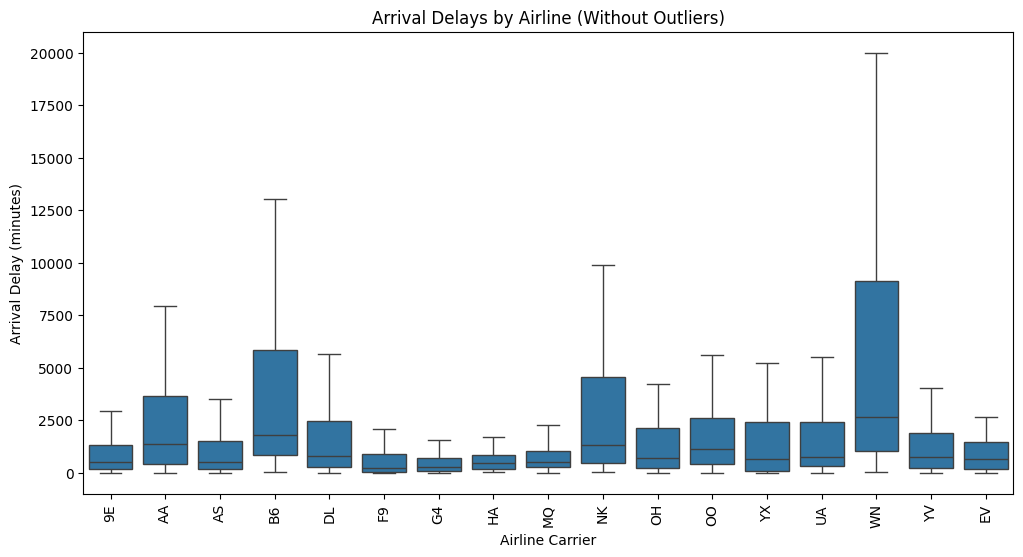

In [ ]:
# Boxplot of delays by airline
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="carrier", y="arr_delay", showfliers=False)
plt.xticks(rotation=90)
plt.title("Arrival Delays by Airline (Without Outliers)")
plt.xlabel("Airline Carrier")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

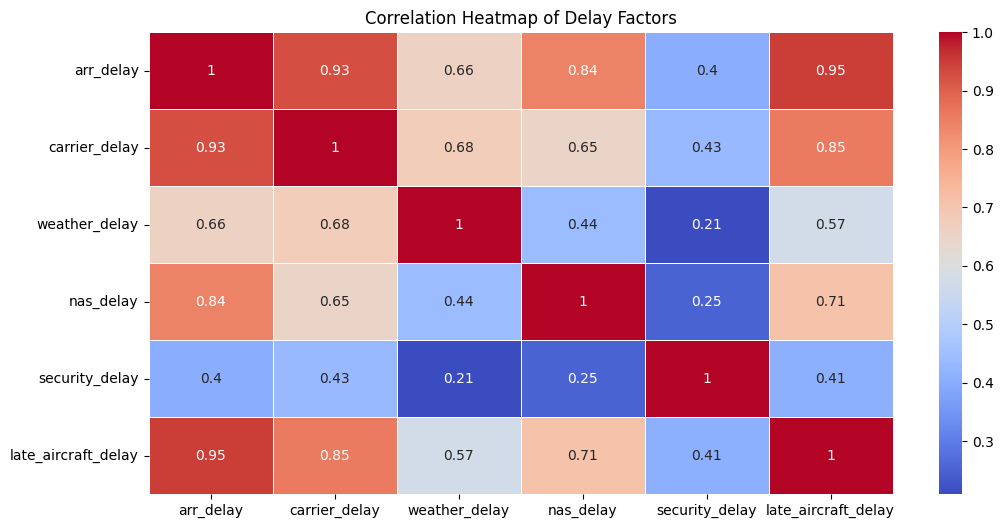

In [ ]:
# Correlation heatmap of delay factors
plt.figure(figsize=(12, 6))
corr_matrix = df[['arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Delay Factors")
plt.show()


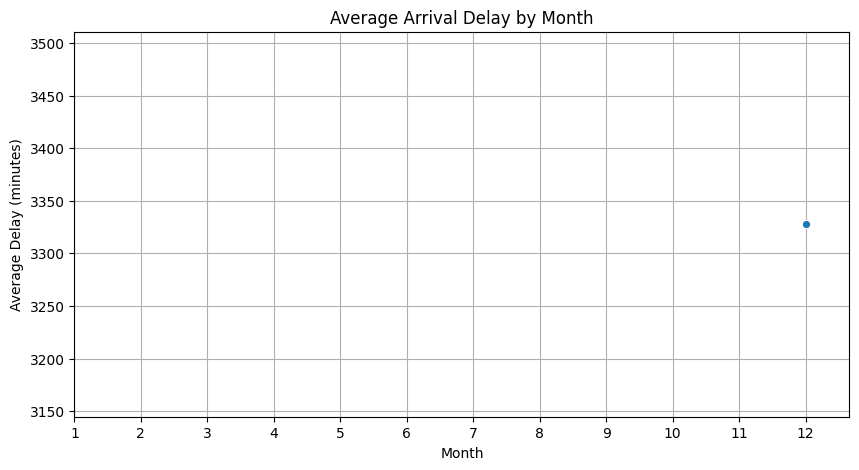

In [ ]:
# Monthly delay trends
monthly_delays = df.groupby("month")["arr_delay"].mean()
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_delays.index, y=monthly_delays.values, marker="o")
plt.xticks(range(1, 13))
plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")
plt.grid(True)
plt.show()

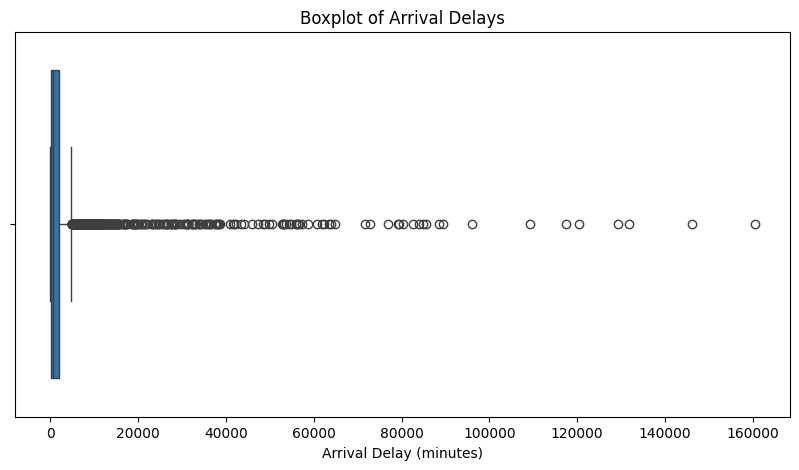

In [ ]:
# Univariate Analysis: Boxplot of arrival delays
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["arr_delay"])
plt.title("Boxplot of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.show()

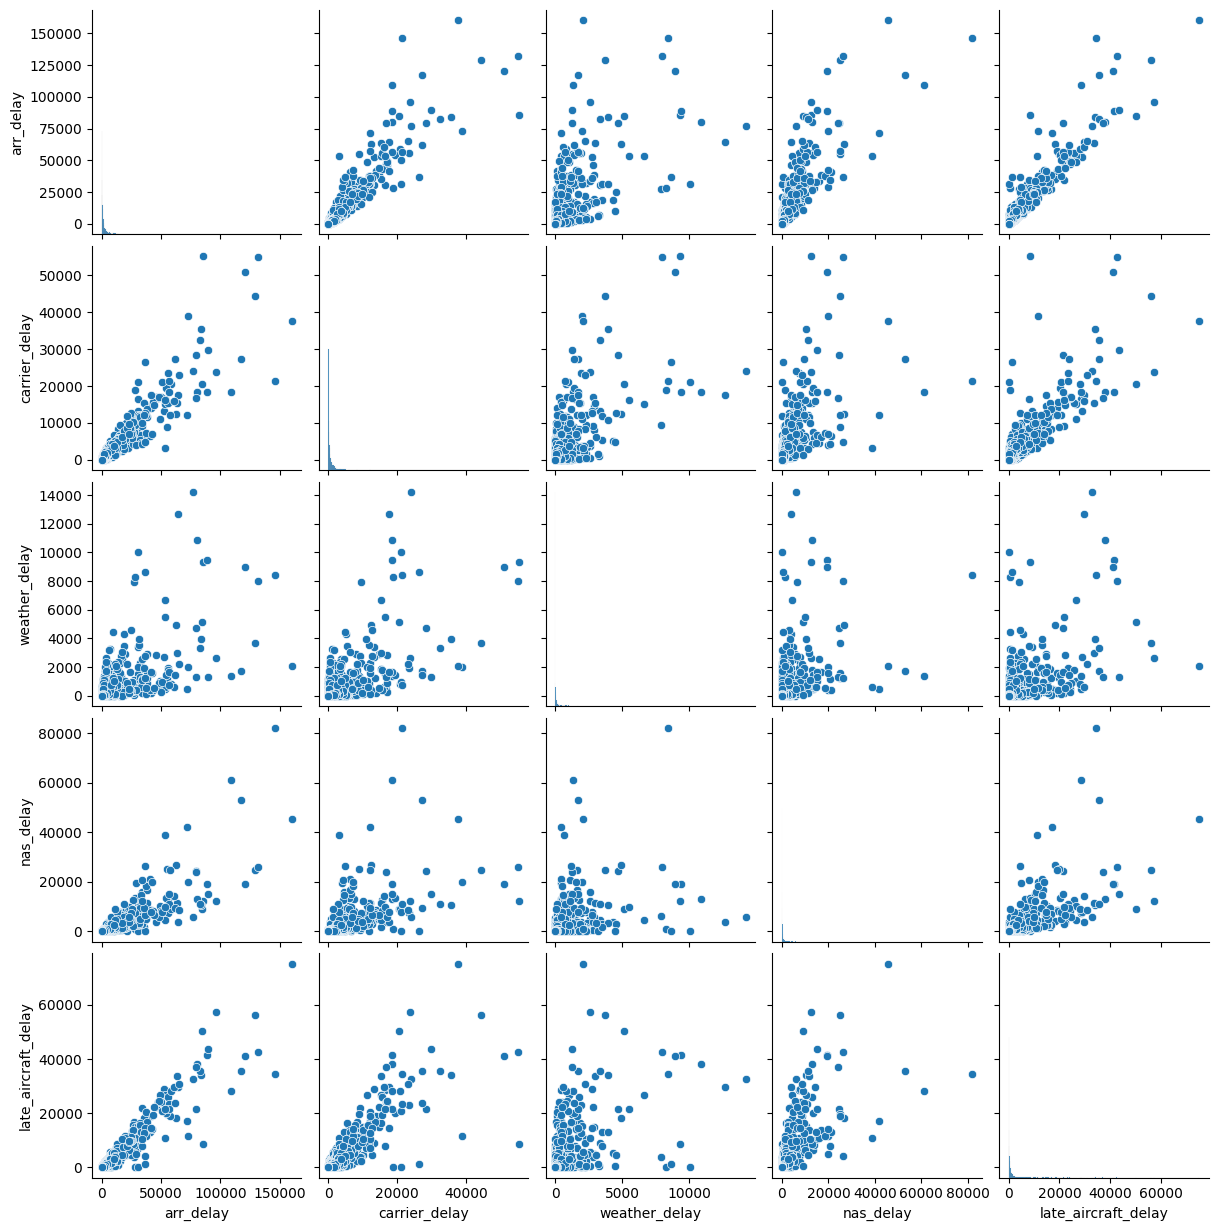

In [ ]:
# Bivariate Analysis: Pairplot to check relationships between key delay factors
sns.pairplot(df[['arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'late_aircraft_delay']])
plt.show()

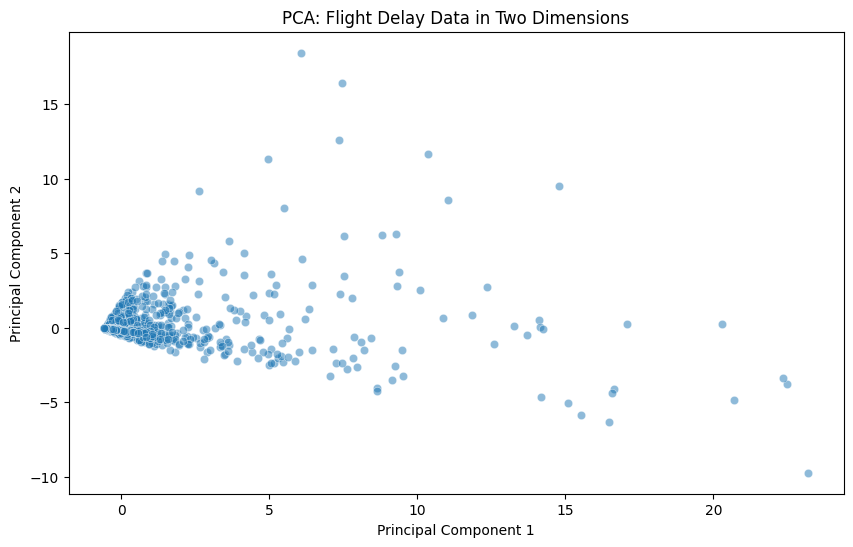

In [ ]:
# Multivariate Analysis: PCA for dimensionality reduction
features = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
df_scaled = StandardScaler().fit_transform(df[features])
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=principal_components[:, 0], y=principal_components[:, 1], alpha=0.5)
plt.title("PCA: Flight Delay Data in Two Dimensions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Here, our dependent variable is 'arr_delay' (arrival delay in minutes)
# Independent variables selected for this analysis are related to flight operations:
# - arr_flights: Number of arriving flights
# - carrier_ct: Count related to carrier performance
# - weather_ct: Count related to weather effects
# - nas_ct: Count related to National Airspace System issues
# - security_ct: Count related to security issues
# - late_aircraft_ct: Count related to late aircraft performance

y = df["arr_delay"]
X = df[["arr_flights", "carrier_ct", "weather_ct", "nas_ct", "security_ct", "late_aircraft_ct"]]

# Adding a constant term for the intercept in the regression model
X = sm.add_constant(X)

In [ ]:
 #4. Splitting the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 5. Choosing and Estimate the Regression Model
# Using Ordinary Least Squares (OLS) Regression from statsmodels
model = sm.OLS(y_train, X_train).fit()

# Print the model summary to assess coefficients, p-values, R-squared, etc.
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              arr_delay   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     8537.
Date:                Sat, 22 Feb 2025   Prob (F-statistic):               0.00
Time:                        02:11:34   Log-Likelihood:                -24503.
No. Observations:                2680   AIC:                         4.902e+04
Df Residuals:                    2673   BIC:                         4.906e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               72.2428     47.307  

In [ ]:
# 6. Evaluating Model Fit
# Predict on the test set
y_pred = model.predict(X_test)

In [ ]:
# Calculating performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error (Test): {:.2f}".format(mse))
print("R-squared (Test): {:.2f}".format(r2))

Mean Squared Error (Test): 5060143.69
R-squared (Test): 0.96


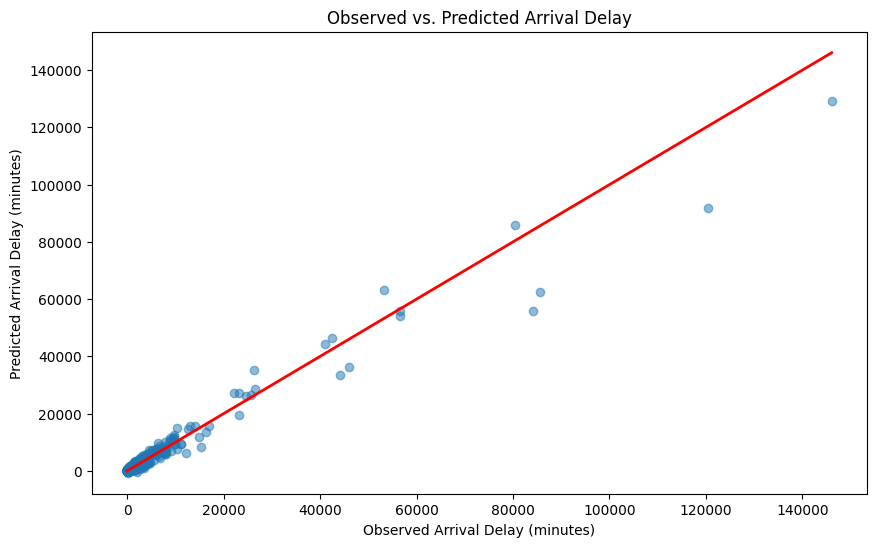

In [ ]:
# Plot Observed vs. Predicted Arrival Delays
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Observed Arrival Delay (minutes)")
plt.ylabel("Predicted Arrival Delay (minutes)")
plt.title("Observed vs. Predicted Arrival Delay")
# Diagonal line for reference (perfect predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.show()

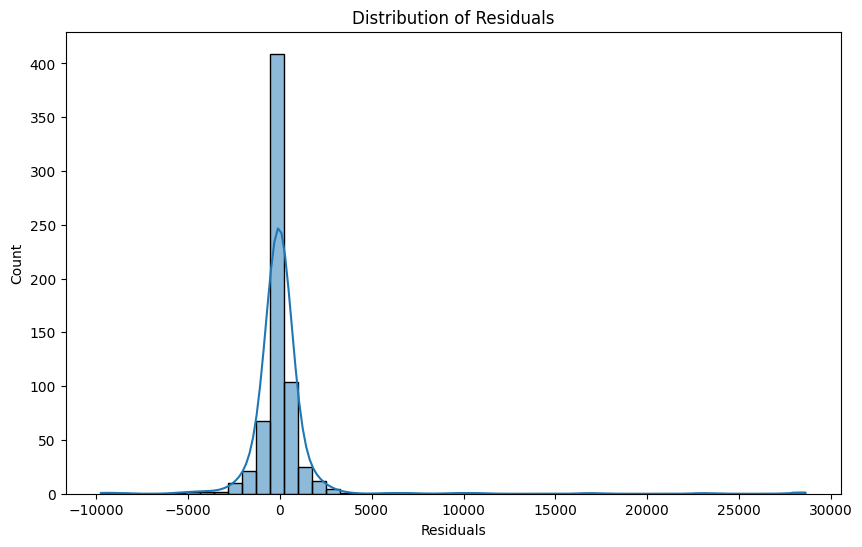

In [ ]:
# 7. Residual Analysis
# Calculate residuals
residuals = y_test - y_pred


# Plot distribution of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()

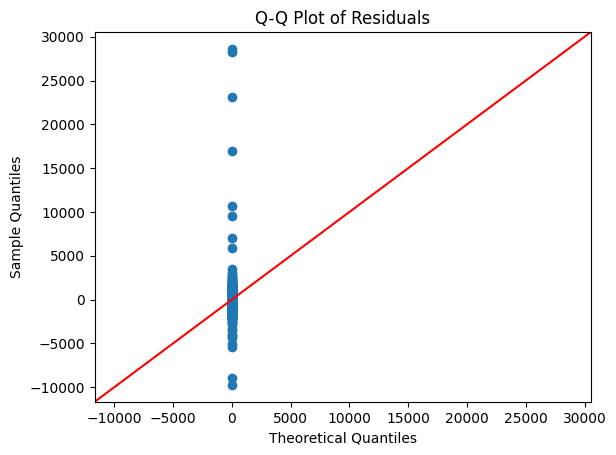

In [ ]:
# Q-Q Plot to assess normality of residuals
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

In [ ]:
#8. Assess Multicollinearity
# Calculate Variance Inflation Factor (VIF) for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("Variance Inflation Factors (VIF):")
print(vif_data)

Variance Inflation Factors (VIF):
            feature       VIF
0             const  1.153821
1       arr_flights  9.454930
2        carrier_ct  7.776636
3        weather_ct  2.171208
4            nas_ct  3.367490
5       security_ct  1.465657
6  late_aircraft_ct  5.053414
